<a href="https://colab.research.google.com/github/madhu-sudhana07/madhusudhana/blob/main/CreditScoreAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df=pd.read_csv('/content/Credit_score.csv')
print(df.iloc[:,:13].head())

       ID Customer_ID     Month           Name   Age          SSN Occupation  \
0  0x1602   CUS_0xd40   January  Aaron Maashoh    23  821-00-0265  Scientist   
1  0x1603   CUS_0xd40  February  Aaron Maashoh    23  821-00-0265  Scientist   
2  0x1604   CUS_0xd40     March  Aaron Maashoh  -500  821-00-0265  Scientist   
3  0x1605   CUS_0xd40     April  Aaron Maashoh    23  821-00-0265  Scientist   
4  0x1606   CUS_0xd40       May  Aaron Maashoh    23  821-00-0265  Scientist   

  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  \
0      19114.12            1824.843333                  3                4   
1      19114.12                    NaN                  3                4   
2      19114.12                    NaN                  3                4   
3      19114.12                    NaN                  3                4   
4      19114.12            1824.843333                  3                4   

   Interest_Rate Num_of_Loan  
0              3   

In [ ]:
print(df.iloc[:,13:28].head())

                                        Type_of_Loan  Delay_from_due_date  \
0  Auto Loan, Credit-Builder Loan, Personal Loan,...                    3   
1  Auto Loan, Credit-Builder Loan, Personal Loan,...                   -1   
2  Auto Loan, Credit-Builder Loan, Personal Loan,...                    3   
3  Auto Loan, Credit-Builder Loan, Personal Loan,...                    5   
4  Auto Loan, Credit-Builder Loan, Personal Loan,...                    6   

  Num_of_Delayed_Payment Changed_Credit_Limit  Num_Credit_Inquiries  \
0                      7                11.27                   4.0   
1                    NaN                11.27                   4.0   
2                      7                    _                   4.0   
3                      4                 6.27                   4.0   
4                    NaN                11.27                   4.0   

  Credit_Mix Outstanding_Debt  Credit_Utilization_Ratio  \
0          _           809.98                 26.82

In [ ]:
# Rows and columns of dataframe
df.shape

(100000, 27)

In [ ]:
# Dropping unwanted columns
df.drop(['ID','Name','SSN'],axis=1,inplace=True)

In [ ]:
# info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Customer_ID               100000 non-null  object 
 1   Month                     100000 non-null  object 
 2   Age                       100000 non-null  object 
 3   Occupation                100000 non-null  object 
 4   Annual_Income             100000 non-null  object 
 5   Monthly_Inhand_Salary     84998 non-null   float64
 6   Num_Bank_Accounts         100000 non-null  int64  
 7   Num_Credit_Card           100000 non-null  int64  
 8   Interest_Rate             100000 non-null  int64  
 9   Num_of_Loan               100000 non-null  object 
 10  Type_of_Loan              88592 non-null   object 
 11  Delay_from_due_date       100000 non-null  int64  
 12  Num_of_Delayed_Payment    92998 non-null   object 
 13  Changed_Credit_Limit      100000 non-null  ob

In [ ]:
# column datatypes
df.dtypes

,0
Customer_ID,object
Month,object
Age,object
Occupation,object
Annual_Income,object
Monthly_Inhand_Salary,float64
Num_Bank_Accounts,int64
Num_Credit_Card,int64
Interest_Rate,int64
Num_of_Loan,object


In [ ]:
# Statistical properties
print(df.describe().T)

                             count         mean          std         min  \
Monthly_Inhand_Salary      84998.0  4194.170850  3183.686167  303.645417   
Num_Bank_Accounts         100000.0    17.091280   117.404834   -1.000000   
Num_Credit_Card           100000.0    22.474430   129.057410    0.000000   
Interest_Rate             100000.0    72.466040   466.422621    1.000000   
Delay_from_due_date       100000.0    21.068780    14.860104   -5.000000   
Num_Credit_Inquiries       98035.0    27.754251   193.177339    0.000000   
Credit_Utilization_Ratio  100000.0    32.285173     5.116875   20.000000   
Total_EMI_per_month       100000.0  1403.118217  8306.041270    0.000000   

                                  25%          50%          75%          max  
Monthly_Inhand_Salary     1625.568229  3093.745000  5957.448333  15204.63333  
Num_Bank_Accounts            3.000000     6.000000     7.000000   1798.00000  
Num_Credit_Card              4.000000     5.000000     7.000000   1499.00000  

In [ ]:
# Statistical properties
print(df.describe(include='object').T)

                          count unique                               top  \
Customer_ID              100000  12500                         CUS_0xd40   
Month                    100000      8                           January   
Age                      100000   1788                                38   
Occupation               100000     16                           _______   
Annual_Income            100000  18940                          36585.12   
Num_of_Loan              100000    434                                 3   
Type_of_Loan              88592   6260                     Not Specified   
Num_of_Delayed_Payment    92998    749                                19   
Changed_Credit_Limit     100000   3635                                 _   
Credit_Mix               100000      4                          Standard   
Outstanding_Debt         100000  13178                           1360.45   
Credit_History_Age        90970    404            15 Years and 11 Months   
Payment_of_M

In [ ]:
# Checking for duplicates
df.duplicated().sum()

0

In [ ]:
# Checking for null values
print(df.isnull().sum())

Customer_ID                     0
Month                           0
Age                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit            0
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour               0
Monthly_Balance              1200
dtype: int64


In [ ]:
import pandas as pd

def standardize_age_by_customer_id(df):
  """Standardizes age for each customer ID in a Pandas DataFrame.

  Args:
    df: Pandas DataFrame with columns 'customer_id' and 'age'.

  Returns:
    Pandas DataFrame with standardized age for each customer ID.
  """

  # Group by customer ID and calculate the first age for each group
  age_map = df.groupby('Customer_ID')['Age'].first()

  # Map the standardized age back to the DataFrame
  df['Age'] = df['Customer_ID'].map(age_map)

  return df


df = standardize_age_by_customer_id(df)


In [ ]:
print(df.isnull().sum().reset_index().rename(columns={'index': 'column_name', 0: 'null_count'}))

                 column_name  null_count
0                Customer_ID           0
1                      Month           0
2                        Age           0
3                 Occupation           0
4              Annual_Income           0
5      Monthly_Inhand_Salary       15002
6          Num_Bank_Accounts           0
7            Num_Credit_Card           0
8              Interest_Rate           0
9                Num_of_Loan           0
10              Type_of_Loan       11408
11       Delay_from_due_date           0
12    Num_of_Delayed_Payment        7002
13      Changed_Credit_Limit           0
14      Num_Credit_Inquiries        1965
15                Credit_Mix           0
16          Outstanding_Debt           0
17  Credit_Utilization_Ratio           0
18        Credit_History_Age        9030
19     Payment_of_Min_Amount           0
20       Total_EMI_per_month           0
21   Amount_invested_monthly        4479
22         Payment_Behaviour           0
23           Mon

In [ ]:
import pandas as pd

def standardize_monthly_Inhandsalary_customer_id(df):
  """Standardizes age for each customer ID in a Pandas DataFrame.

  Args:
    df: Pandas DataFrame with columns 'customer_id' and 'age'.

  Returns:
    Pandas DataFrame with standardized age for each customer ID.
  """

  # Group by customer ID and calculate the first age for each group
  salary_map = df.groupby('Customer_ID')['Monthly_Inhand_Salary'].first()

  # Map the standardized age back to the DataFrame
  df['Monthly_Inhand_Salary'] = df['Customer_ID'].map(salary_map)

  return df


df = standardize_monthly_Inhandsalary_customer_id(df)


In [ ]:
import pandas as pd

def remove_trailing_underscore_from_age(df, age_column):
  """
  Removes trailing underscores from numbers in the specified age column.

  Args:
    df: The pandas DataFrame containing the data.
    age_column: The name of the age column.

  Returns:
    The DataFrame with cleaned age values.
  """

  def clean_age(age):
    if isinstance(age, str) and age.endswith('_'):
      return age[:-1]
    else:
      return age

  df[age_column] = df[age_column].apply(clean_age)
  return df
df = remove_trailing_underscore_from_age(df, 'Age')

In [ ]:
df["Age"]=df["Age"].astype(int)

In [ ]:
df = remove_trailing_underscore_from_age(df, 'Outstanding_Debt')
df['Outstanding_Debt']=df['Outstanding_Debt'].astype(float)

In [ ]:
df = remove_trailing_underscore_from_age(df, 'Num_of_Delayed_Payment')
df['Num_of_Delayed_Payment']=df['Num_of_Delayed_Payment'].astype(float)

In [ ]:
df = remove_trailing_underscore_from_age(df, 'Annual_Income')
df['Annual_Income']=df['Annual_Income'].astype(float)

In [ ]:
df = remove_trailing_underscore_from_age(df, 'Num_of_Loan')
df['Num_of_Loan']=df['Num_of_Loan'].astype(int)

In [ ]:
# Remove leading and trailing underscores from the "amount_invested" column
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].str.strip('_')

# Convert the "amount_invested" column to float
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].astype(float)


In [ ]:
df["Occupation"]=df["Occupation"].replace("_______",np.NaN)

In [ ]:
import pandas as pd

def standardize_occupation_customer_id(df):
  """Standardizes age for each customer ID in a Pandas DataFrame.

  Args:
    df: Pandas DataFrame with columns 'customer_id' and 'age'.

  Returns:
    Pandas DataFrame with standardized age for each customer ID.
  """

  # Group by customer ID and calculate the first age for each group
  occup_map = df.groupby('Customer_ID')["Occupation"].agg(pd.Series.mode) # Use agg to apply mode to each group

  # Map the standardized age back to the DataFrame
  df["Occupation"] = df['Customer_ID'].map(occup_map)

  return df


df = standardize_occupation_customer_id(df)

In [ ]:
df["Credit_Mix"]=df["Credit_Mix"].replace("_",np.nan)

In [ ]:
df["Changed_Credit_Limit"]=df["Changed_Credit_Limit"].replace("_",np.nan)

In [ ]:
df["Payment_Behaviour"]=df["Payment_Behaviour"].replace("!@9#%8",np.nan)

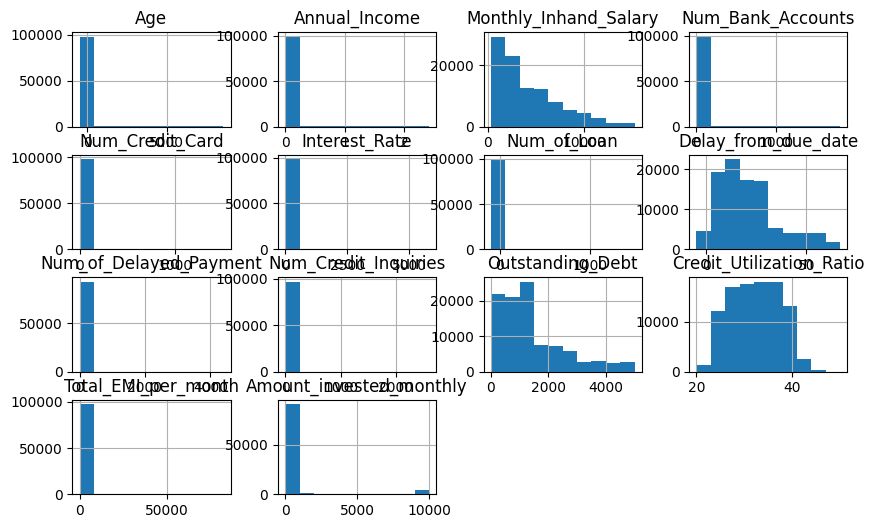

Customer_ID
CUS_0xd40     8
CUS_0x9bf4    8
CUS_0x5ae3    8
CUS_0xbe9a    8
CUS_0x4874    8
             ..
CUS_0x2eb4    8
CUS_0x7863    8
CUS_0x9d89    8
CUS_0xc045    8
CUS_0x942c    8
Name: count, Length: 12500, dtype: int64
Month
January     12500
February    12500
March       12500
April       12500
May         12500
June        12500
July        12500
August      12500
Name: count, dtype: int64
Occupation
Lawyer           7096
Engineer         6864
Architect        6824
Mechanic         6776
Scientist        6744
Accountant       6744
Developer        6720
Media_Manager    6720
Teacher          6672
Entrepreneur     6648
Doctor           6568
Journalist       6536
Manager          6432
Musician         6352
Writer           6304
Name: count, dtype: int64
Type_of_Loan
Not Specified                                                                                                                         1408
Credit-Builder Loan                                                         

In [ ]:
df.hist(figsize=(10, 6))
plt.show()

# Check the unique values and counts of categorical columns
for col in df.select_dtypes(include=['object']):
  print(df[col].value_counts())

# Check the correlation matrix for numerical columns
if df.select_dtypes(include=[np.number]).shape[1] > 1:
  print(df.select_dtypes(include=[np.number]).corr())

In [ ]:
df.drop(df[df["Monthly_Balance"]=="__-333333333333333333333333333__"].index,inplace=True)
df['Monthly_Balance']=df['Monthly_Balance'].astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99991 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               99991 non-null  object 
 1   Month                     99991 non-null  object 
 2   Age                       99991 non-null  int64  
 3   Occupation                99991 non-null  object 
 4   Annual_Income             99991 non-null  float64
 5   Monthly_Inhand_Salary     99991 non-null  float64
 6   Num_Bank_Accounts         99991 non-null  int64  
 7   Num_Credit_Card           99991 non-null  int64  
 8   Interest_Rate             99991 non-null  int64  
 9   Num_of_Loan               99991 non-null  int64  
 10  Type_of_Loan              88583 non-null  object 
 11  Delay_from_due_date       99991 non-null  int64  
 12  Num_of_Delayed_Payment    92989 non-null  float64
 13  Changed_Credit_Limit      97900 non-null  object 
 14  Num_Credit_

#EDA

In [ ]:
cat_cols=df.select_dtypes(include="object")
num_cols=df.select_dtypes(include=np.number)

Categorical Data

In [ ]:
print(cat_cols.describe().T)

                       count unique                             top   freq
Customer_ID            99991  12500                       CUS_0xd40      8
Month                  99991      8                         January  12500
Occupation             99991     15                          Lawyer   7095
Type_of_Loan           88583   6260                   Not Specified   1408
Changed_Credit_Limit   97900   3634                            8.22    135
Credit_Mix             79798      3                        Standard  36476
Credit_History_Age     90962    404          15 Years and 11 Months    446
Payment_of_Min_Amount  99991      3                             Yes  52323
Payment_Behaviour      92391      6  Low_spent_Small_value_payments  25509


In [ ]:
for col in cat_cols:
  print(cat_cols[col].value_counts())
  print("-"*50)

Customer_ID
CUS_0xd40     8
CUS_0x8d2     8
CUS_0x48f     8
CUS_0x29b4    8
CUS_0x5ae3    8
             ..
CUS_0x57f3    7
CUS_0x2f7e    7
CUS_0x2b77    7
CUS_0x288d    7
CUS_0x5a90    7
Name: count, Length: 12500, dtype: int64
--------------------------------------------------
Month
January     12500
May         12500
June        12500
March       12499
April       12499
August      12499
February    12497
July        12497
Name: count, dtype: int64
--------------------------------------------------
Occupation
Lawyer           7095
Engineer         6863
Architect        6824
Mechanic         6775
Scientist        6744
Accountant       6744
Media_Manager    6720
Developer        6719
Teacher          6672
Entrepreneur     6648
Doctor           6566
Journalist       6534
Manager          6432
Musician         6351
Writer           6304
Name: count, dtype: int64
--------------------------------------------------
Type_of_Loan
Not Specified                                                 

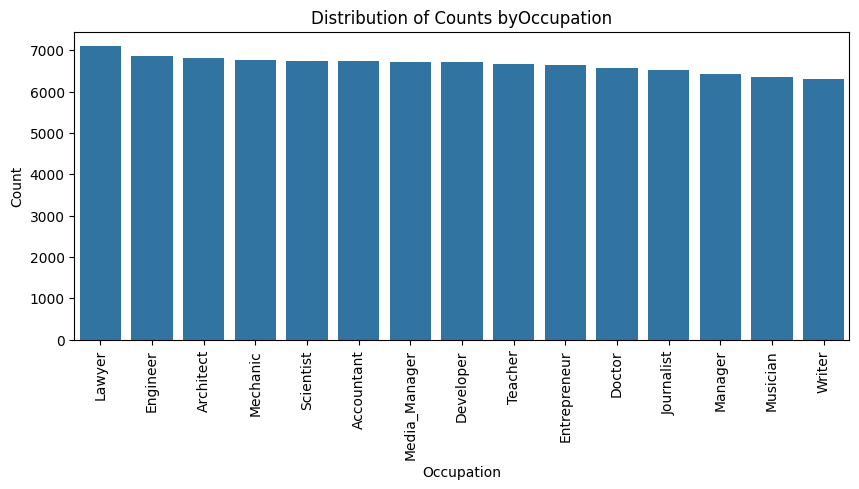

In [ ]:
#Occupation
plt.figure(figsize=(10,4))
ax=sns.countplot(data=cat_cols,x="Occupation",order=df["Occupation"].value_counts().index)
plt.xticks(rotation=90)
plt.title("Distribution of Counts byOccupation")
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.show()


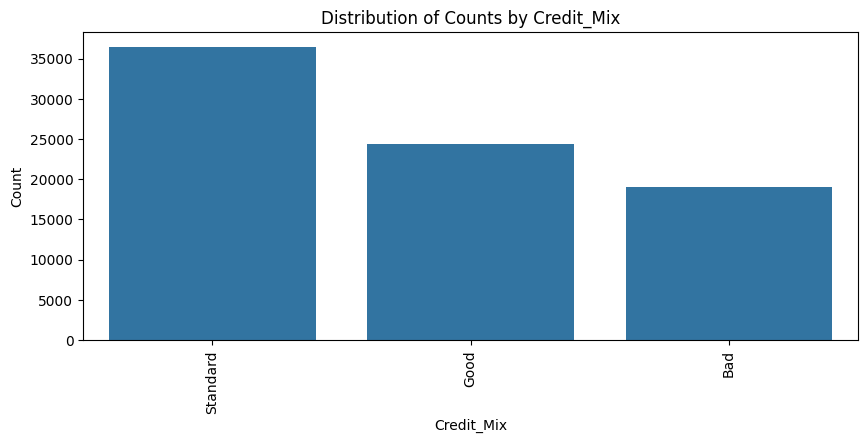

In [ ]:
#Credit Mix
plt.figure(figsize=(10,4))
ax=sns.countplot(data=cat_cols,x="Credit_Mix",order=df["Credit_Mix"].value_counts().index)
plt.xticks(rotation=90)
plt.title("Distribution of Counts by Credit_Mix")
plt.xlabel("Credit_Mix")
plt.ylabel("Count")
plt.show()


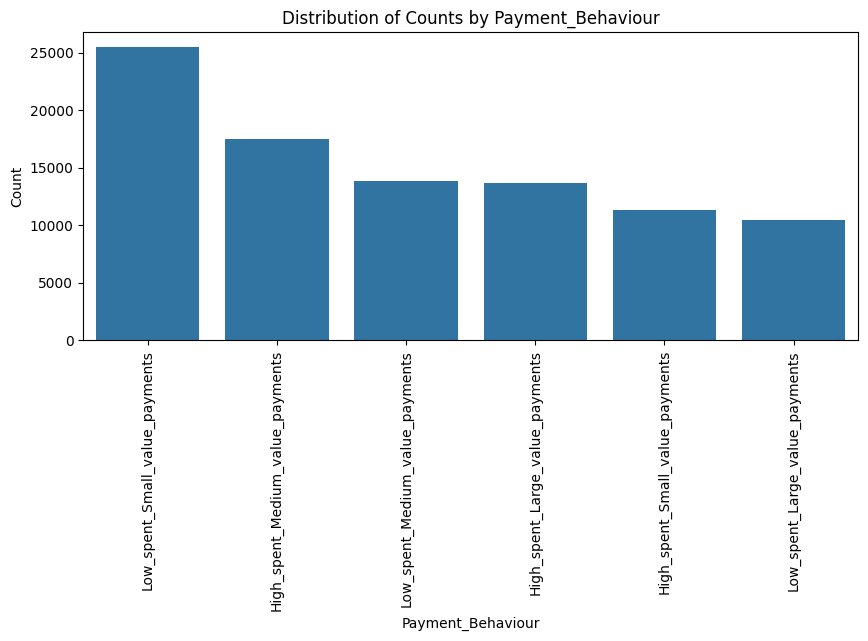

In [ ]:
#Payment_Behaviour
plt.figure(figsize=(10,4))
ax=sns.countplot(data=cat_cols,x="Payment_Behaviour",order=df["Payment_Behaviour"].value_counts().index)
plt.xticks(rotation=90)
plt.title("Distribution of Counts by Payment_Behaviour")
plt.xlabel("Payment_Behaviour")
plt.ylabel("Count")
plt.show()

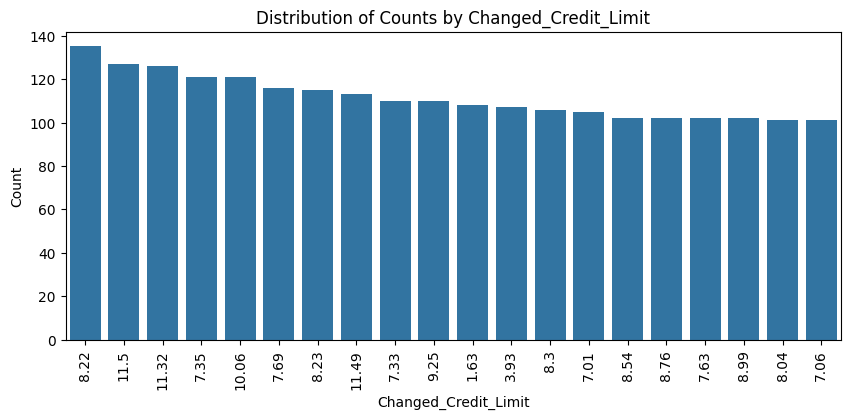

In [ ]:
#Changed_Credit_Limit
plt.figure(figsize=(10,4))
ax=sns.countplot(data=cat_cols,x="Changed_Credit_Limit",order=df["Changed_Credit_Limit"].value_counts().iloc[:20].index)
plt.xticks(rotation=90)
plt.title("Distribution of Counts by Changed_Credit_Limit")
plt.xlabel("Changed_Credit_Limit")
plt.ylabel("Count")
plt.show()

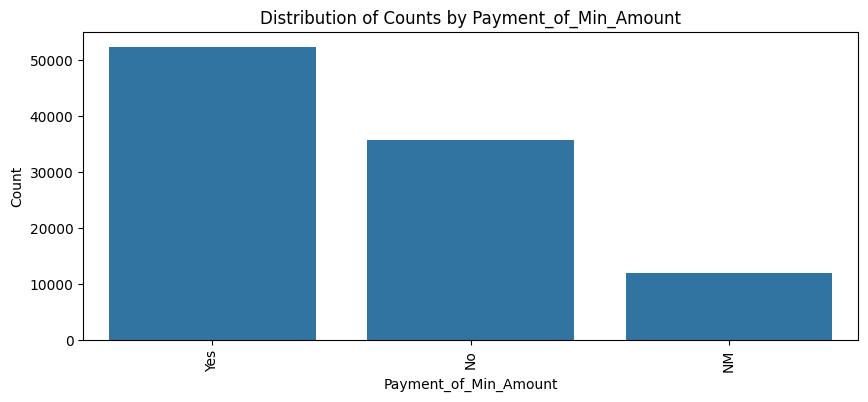

In [ ]:
#Payment_of_Min_Amount
plt.figure(figsize=(10,4))
ax=sns.countplot(data=cat_cols,x="Payment_of_Min_Amount",order=df["Payment_of_Min_Amount"].value_counts().index)
plt.xticks(rotation=90)
plt.title("Distribution of Counts by Payment_of_Min_Amount")
plt.xlabel("Payment_of_Min_Amount")
plt.ylabel("Count")
plt.show()

# Numerical Data

In [ ]:
print(num_cols.describe().T)

                            count           mean           std          min  \
Age                       99991.0     113.378324  6.912298e+02  -500.000000   
Annual_Income             99991.0  176426.789475  1.429682e+06  7005.930000   
Monthly_Inhand_Salary     99991.0    4208.468407  3.194818e+03   303.645417   
Num_Bank_Accounts         99991.0      17.092458  1.174101e+02    -1.000000   
Num_Credit_Card           99991.0      22.475983  1.290631e+02     0.000000   
Interest_Rate             99991.0      72.471562  4.664432e+02     1.000000   
Num_of_Loan               99991.0       3.009941  6.265069e+01  -100.000000   
Delay_from_due_date       99991.0      21.069406  1.486052e+01    -5.000000   
Num_of_Delayed_Payment    92989.0      30.925400  2.260427e+02    -3.000000   
Num_Credit_Inquiries      98026.0      27.756187  1.931861e+02     0.000000   
Outstanding_Debt          99991.0    1426.235360  1.155140e+03     0.230000   
Credit_Utilization_Ratio  99991.0      32.284965  5.

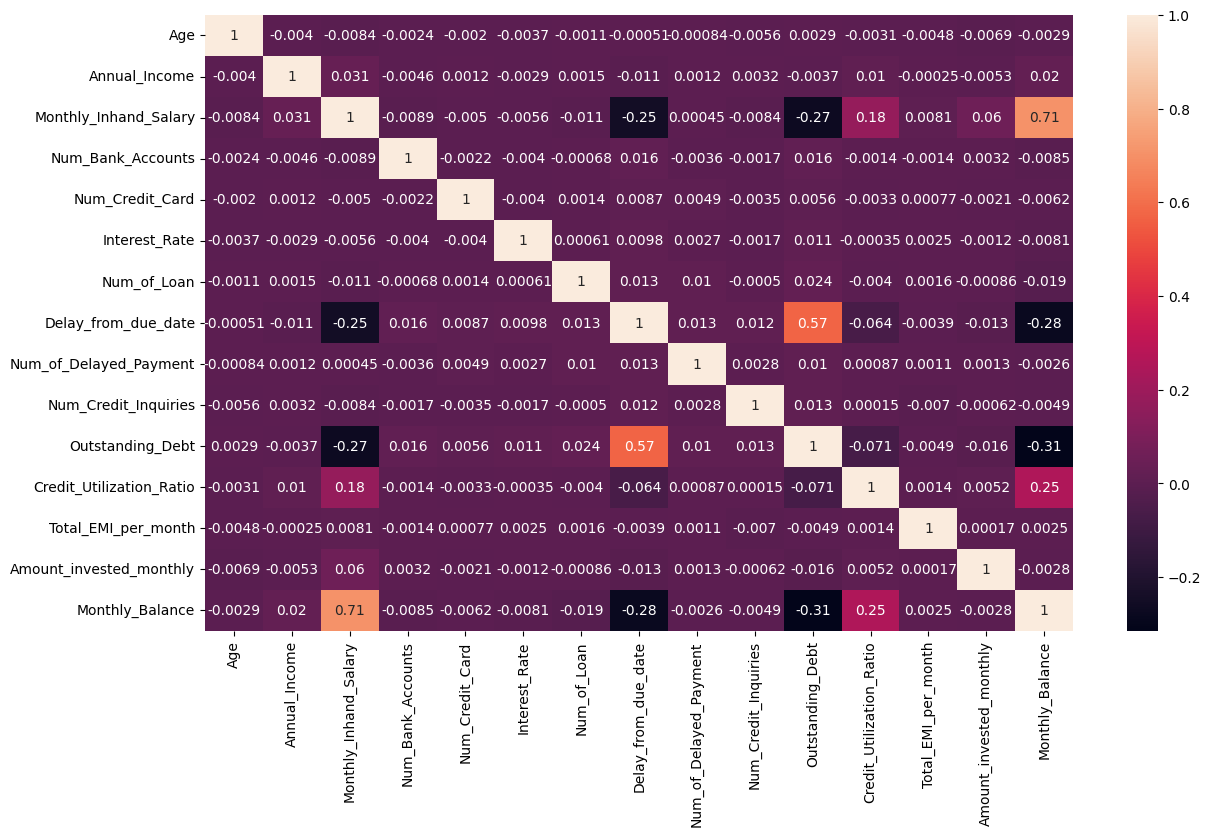

In [ ]:
corrmat=num_cols.corr()
plt.figure(figsize=(14,8))
sns.heatmap(corrmat,annot=True)
plt.show()

In [ ]:
!pip install statsmodels
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

vf_df = num_cols.copy() # Create a copy to avoid modifying original
vf_df.dropna(inplace=True) # Drop rows with missing values
vf_df.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace infinite values with NaN, if any
vf_df.dropna(inplace=True) # Drop rows with infinite values

vf_data = pd.DataFrame()
vf_data["Features"] = vf_df.columns
# Calculate VIF for each feature
vf_data["VIF"] = [variance_inflation_factor(vf_df.values, i) for i in range(vf_df.shape[1])]
print(vf_data)

                    Features       VIF
0                        Age  1.026482
1              Annual_Income  1.016215
2      Monthly_Inhand_Salary  5.501595
3          Num_Bank_Accounts  1.021032
4            Num_Credit_Card  1.029873
5              Interest_Rate  1.024194
6                Num_of_Loan  1.003156
7        Delay_from_due_date  4.412501
8     Num_of_Delayed_Payment  1.018768
9       Num_Credit_Inquiries  1.020366
10          Outstanding_Debt  3.828622
11  Credit_Utilization_Ratio  9.445327
12       Total_EMI_per_month  1.028299
13   Amount_invested_monthly  1.100158
14           Monthly_Balance  9.625094


In [ ]:
def preprocess_data(data, mvi_groupby=None, mvi_customval=None, column=None,unwanted_value_replace=None, unwanted_value_strip=None, datatype=None):
# stripping unwanted values that might be at the beginning or end of the value
  if unwanted_value_strip is not None:
    if data[column].dtype == object:
      data[column] = data[column].str.strip(unwanted_value_strip)
  print(f"\nTrailing & leading {unwanted_value_strip} are removed")
  # replacing unwanted value with NaN
  if unwanted_value_replace is not None:
    data[column] = data[column].replace(unwanted_value_replace, np.nan)
  print(f"\nUnwanted value {unwanted_value_replace} is replaced with NaN")
  # performing missing value imputation (mvi) using mode after grouping data using the column specified by the user
  if mvi_groupby and column:
    data[column] = data[column].replace('', np.nan)
    group_mode = data.groupby(mvi_groupby)[column].transform(lambda x: x.mode().iat[0])
    data[column] = data[column].fillna(group_mode)
  print("\nMissing values imputed with group mode")
  # performing missing value imputation using a user provided custom value
  if mvi_customval is not None:
    data[column] = data[column].replace('', np.nan)
    data[column].replace([np.NaN], mvi_customval, inplace=True)
  print(f"\nMissing values are replaced with '{mvi_customval}'")
  # changing the data type of the column based on user provided data type
  if datatype is not None:
    data[column] = data[column].astype(datatype)
  print(f"\nDatatype of {column} is changed to {datatype}")
  print('----------------------------------------------------')

In [ ]:
# creating a function that picks the year and month and then combines them to give total number of months
def credit_history_in_months(val):
  if pd.notnull(val):
    years = int(val.split(' ')[0])
    month = int(val.split(' ')[3])
    return (years*12)+month
  else:
    return val
# applying the function to the column
df['Credit_History_Age'] = df['Credit_History_Age'].apply(lambda x:credit_history_in_months(x)).astype(float)
print('Column: Credit_History_Age')
preprocess_data(data = df,column = 'Credit_History_Age',mvi_groupby = 'Customer_ID')

Column: Credit_History_Age

Trailing & leading None are removed

Unwanted value None is replaced with NaN

Missing values imputed with group mode

Missing values are replaced with 'None'

Datatype of Credit_History_Age is changed to None
----------------------------------------------------


In [ ]:
print("Column: Type_of_Loan")
preprocess_data(data = df,column = 'Type_of_Loan',mvi_customval = 'Not Specified')

Column: Type_of_Loan

Trailing & leading None are removed

Unwanted value None is replaced with NaN

Missing values imputed with group mode

Missing values are replaced with 'Not Specified'

Datatype of Type_of_Loan is changed to None
----------------------------------------------------


In [ ]:
print("Column: Credit_Mix")
preprocess_data(data = df,column = 'Credit_Mix',unwanted_value_replace = '_',mvi_groupby = 'Customer_ID')


Column: Credit_Mix

Trailing & leading None are removed

Unwanted value _ is replaced with NaN

Missing values imputed with group mode

Missing values are replaced with 'None'

Datatype of Credit_Mix is changed to None
----------------------------------------------------


In [ ]:
print("Column: Payment_Behaviour")
preprocess_data(data = df,column = 'Payment_Behaviour',unwanted_value_replace = '!@9#%8',mvi_groupby = 'Customer_ID')


Column: Payment_Behaviour

Trailing & leading None are removed

Unwanted value !@9#%8 is replaced with NaN

Missing values imputed with group mode

Missing values are replaced with 'None'

Datatype of Payment_Behaviour is changed to None
----------------------------------------------------


In [ ]:
print("Column: Monthly_Inhand_Salary")
preprocess_data(data = df,column = 'Monthly_Inhand_Salary',mvi_groupby = 'Customer_ID')

Column: Monthly_Inhand_Salary

Trailing & leading None are removed

Unwanted value None is replaced with NaN

Missing values imputed with group mode

Missing values are replaced with 'None'

Datatype of Monthly_Inhand_Salary is changed to None
----------------------------------------------------


In [ ]:
print("Column: Num_Credit_Inquiries")
preprocess_data(data = df,column = 'Num_Credit_Inquiries',mvi_groupby = 'Customer_ID')

Column: Num_Credit_Inquiries

Trailing & leading None are removed

Unwanted value None is replaced with NaN

Missing values imputed with group mode

Missing values are replaced with 'None'

Datatype of Num_Credit_Inquiries is changed to None
----------------------------------------------------


In [ ]:
print("Column: Outstanding_Debt")
preprocess_data(data = df,column = 'Outstanding_Debt',unwanted_value_strip = '_',mvi_groupby = 'Customer_ID',datatype = 'float')


Column: Outstanding_Debt

Trailing & leading _ are removed

Unwanted value None is replaced with NaN

Missing values imputed with group mode

Missing values are replaced with 'None'

Datatype of Outstanding_Debt is changed to float
----------------------------------------------------


In [ ]:
print("Column: Changed_Credit_Limit")
preprocess_data(data = df,column = 'Changed_Credit_Limit',unwanted_value_strip = '_',unwanted_value_replace = '_',mvi_groupby = 'Customer_ID',datatype = 'float')

Column: Changed_Credit_Limit

Trailing & leading _ are removed

Unwanted value _ is replaced with NaN

Missing values imputed with group mode

Missing values are replaced with 'None'

Datatype of Changed_Credit_Limit is changed to float
----------------------------------------------------


In [ ]:
print("Column: Monthly_Balance")
preprocess_data(data = df,column = 'Monthly_Balance',unwanted_value_strip = '_',unwanted_value_replace = '__-333333333333333333333333333__',mvi_groupby = 'Customer_ID',datatype = 'float')

Column: Monthly_Balance

Trailing & leading _ are removed

Unwanted value __-333333333333333333333333333__ is replaced with NaN

Missing values imputed with group mode

Missing values are replaced with 'None'

Datatype of Monthly_Balance is changed to float
----------------------------------------------------


In [ ]:
print("Column: Num_of_Delayed_Payment")
preprocess_data(data = df,column = 'Num_of_Delayed_Payment',unwanted_value_strip = '_',mvi_groupby = 'Customer_ID',datatype = 'float')

Column: Num_of_Delayed_Payment

Trailing & leading _ are removed

Unwanted value None is replaced with NaN

Missing values imputed with group mode

Missing values are replaced with 'None'

Datatype of Num_of_Delayed_Payment is changed to float
----------------------------------------------------


In [ ]:
print("Column: Amount_invested_monthly")
preprocess_data(data = df,column = 'Amount_invested_monthly',unwanted_value_strip = '_',mvi_groupby = 'Customer_ID',datatype = 'float')

Column: Amount_invested_monthly

Trailing & leading _ are removed

Unwanted value None is replaced with NaN

Missing values imputed with group mode

Missing values are replaced with 'None'

Datatype of Amount_invested_monthly is changed to float
----------------------------------------------------


In [ ]:
print("Column: Num_of_Delayed_Payment")
preprocess_data(data = df,column = 'Num_of_Delayed_Payment',unwanted_value_strip = '_',mvi_groupby = 'Customer_ID',datatype = 'float')


Column: Num_of_Delayed_Payment

Trailing & leading _ are removed

Unwanted value None is replaced with NaN

Missing values imputed with group mode

Missing values are replaced with 'None'

Datatype of Num_of_Delayed_Payment is changed to float
----------------------------------------------------


In [ ]:
print(df.isna().sum())

Customer_ID                 0
Month                       0
Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
dtype: int64


In [ ]:
print("Column: Num_Credit_Inquiries")
preprocess_data(data = df,
column = 'Num_Credit_Inquiries',
mvi_groupby = 'Customer_ID')


Column: Num_Credit_Inquiries

Trailing & leading None are removed

Unwanted value None is replaced with NaN

Missing values imputed with group mode

Missing values are replaced with 'None'

Datatype of Num_Credit_Inquiries is changed to None
----------------------------------------------------


#Outlier

In [ ]:
def outlier_capping(data, threshold=1.5):
  # making a copy of the input DataFrame
  data_copy = data.copy()
  # creating a empty list to save the outlier indices
  outlier_indices = []
  # calculating quartile 1 and 3 for every numerical column in the data
  for column in data_copy.columns:
    if pd.api.types.is_numeric_dtype(data_copy[column]):
    # calculating quartiles
      Q1 = data_copy[column].quantile(0.25)
      Q3 = data_copy[column].quantile(0.75)
      # calculating inter-quartile range
      IQR = Q3 - Q1
      # defining the upper and lower outlier bounds
      lower_bound = Q1 - threshold * IQR
      upper_bound = Q3 + threshold * IQR
      # identifying outliers
      outliers = data_copy[(data_copy[column] < lower_bound) | (data_copy[column] >upper_bound)]
      outlier_indices.extend(outliers.index)
      # capping outliers
      data_copy[column] = np.where(data_copy[column] < lower_bound, lower_bound,data_copy[column])
      data_copy[column] = np.where(data_copy[column] > upper_bound,upper_bound, data_copy[column])
      # removing duplicates from outlier_indices list
      outlier_indices = list(set(outlier_indices))
      # returning the dataframe with capped outliers
  return data_copy, outlier_indices
  # running the function to cap all the outliers in the data



In [ ]:
df_clean, outliers = outlier_capping(df)

In [ ]:
print(df_clean)

      Customer_ID     Month   Age Occupation  Annual_Income  \
0       CUS_0xd40   January  23.0  Scientist       19114.12   
1       CUS_0xd40  February  23.0  Scientist       19114.12   
2       CUS_0xd40     March  23.0  Scientist       19114.12   
3       CUS_0xd40     April  23.0  Scientist       19114.12   
4       CUS_0xd40       May  23.0  Scientist       19114.12   
...           ...       ...   ...        ...            ...   
99995  CUS_0x942c     April  24.0   Mechanic       39628.99   
99996  CUS_0x942c       May  24.0   Mechanic       39628.99   
99997  CUS_0x942c      June  24.0   Mechanic       39628.99   
99998  CUS_0x942c      July  24.0   Mechanic       39628.99   
99999  CUS_0x942c    August  24.0   Mechanic       39628.99   

       Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  \
0                1824.843333                3.0              4.0   
1                1824.843333                3.0              4.0   
2                1824.843333           

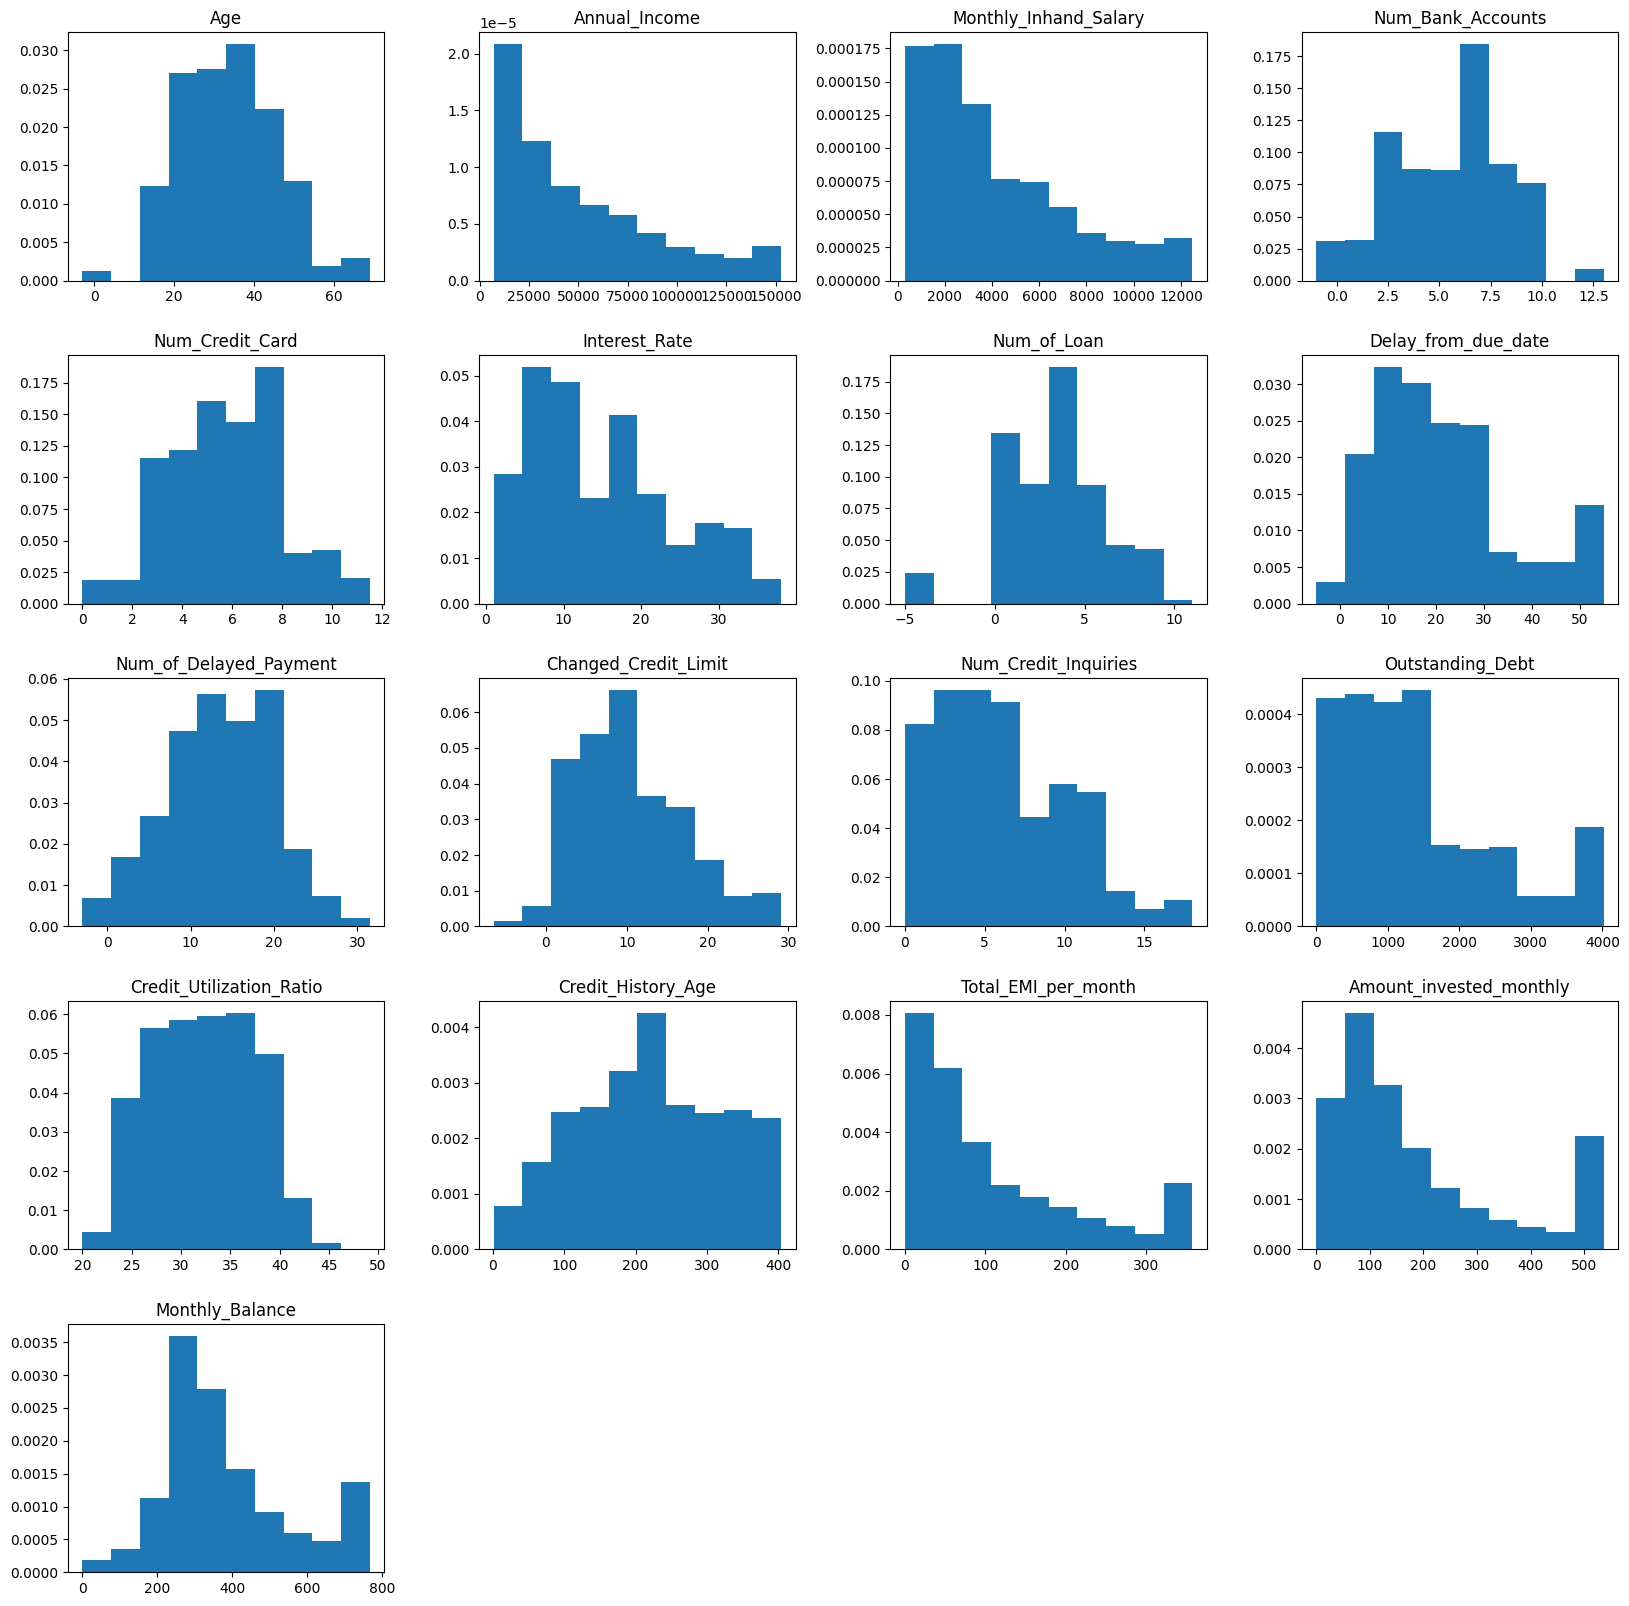

In [ ]:
df_clean.hist(figsize=(20, 20), grid=False, density=True)
plt.show()


In [ ]:
# Select relevant features (example)
features = ['Annual_Income', 'Monthly_Inhand_Salary', 'Num_of_Loan', 'Outstanding_Debt',
            'Credit_History_Age', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
            'Num_Credit_Inquiries', 'Amount_invested_monthly', 'Monthly_Balance']

# Standardize the features (important for fair comparison)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_clean[features])

# Assign weights to each feature (example)
weights = [0.2, 0.15, 0.1, 0.1, 0.1, 0.1, 0.05, 0.05, 0.05, 0.05]

# Calculate the weighted sum for each customer
df_clean['Credit_Score'] = np.dot(scaled_features, weights)

# Scale the credit score to a range (e.g., 300-850)
from sklearn.preprocessing import MinMaxScaler
scaler_score = MinMaxScaler(feature_range=(300, 850))
df_clean['Credit_Score'] = scaler_score.fit_transform(df_clean[['Credit_Score']])

# Round the credit score to an integer
df_clean['Credit_Score'] = df_clean['Credit_Score'].round().astype(int)

# Display the result
print(df_clean[['Customer_ID', 'Credit_Score']].head(20))

   Customer_ID  Credit_Score
0    CUS_0xd40           439
1    CUS_0xd40           430
2    CUS_0xd40           440
3    CUS_0xd40           424
4    CUS_0xd40           429
5    CUS_0xd40           427
6    CUS_0xd40           445
7    CUS_0xd40           434
8   CUS_0x21b1           441
9   CUS_0x21b1           431
10  CUS_0x21b1           422
11  CUS_0x21b1           438
12  CUS_0x21b1           434
13  CUS_0x21b1           426
14  CUS_0x21b1           440
15  CUS_0x21b1           443
16  CUS_0x2dbc           694
17  CUS_0x2dbc           692
18  CUS_0x2dbc           719
19  CUS_0x2dbc           692


In [ ]:
max_credit_score = df_clean['Credit_Score'].max()
min_credit_score = df_clean['Credit_Score'].min()

In [ ]:
df_clean[df_clean['Credit_Score']== max_credit_score]

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
67073,CUS_0xbab8,February,47.0,Musician,152792.5575,12485.4725,3.0,4.0,3.0,11.0,...,Good,171.93,34.145704,286.0,No,285.631602,536.138712,Low_spent_Medium_value_payments,622.487736,850
